# 🐔 Hen Pose Estimation — YOLOv12 Training
**Dataset:** pose-v1 | 99 images | 10 keypoints per hen  
**Keypoints:** tail_base, tail_tip, left_hock, right_hock, left_foot, right_foot, neck_back, middle_back, comb, beak

## 1. Environment Setup

In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 5070, 11752MiB)
Setup complete ✅ (12 CPUs, 30.5 GB RAM, 84.2/456.3 GB disk)


In [2]:
import os
import torch
from pathlib import Path
from ultralytics import YOLO

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.2.2+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 5070
VRAM            : 12.3 GB


## 2. Dataset Verification

In [4]:
import yaml

# ── Set this to your pose-v1 folder ──────────────────────────────────────────
DATASET_ROOT = Path("/home/ogbi/Development/poultry-vision/pose-v1")  # relative to this notebook
# ─────────────────────────────────────────────────────────────────────────────

data_yaml = DATASET_ROOT / "data.yaml"
assert data_yaml.exists(), f"data.yaml not found at {data_yaml}"

with open(data_yaml) as f:
    cfg = yaml.safe_load(f)

train_imgs = list((DATASET_ROOT / "images" / "train").glob("*"))
val_imgs   = list((DATASET_ROOT / "images" / "val").glob("*"))
train_lbls = list((DATASET_ROOT / "labels" / "train").glob("*.txt"))
val_lbls   = list((DATASET_ROOT / "labels" / "val").glob("*.txt"))

print(f"Train images : {len(train_imgs)}")
print(f"Train labels : {len(train_lbls)}")
print(f"Val   images : {len(val_imgs)}")
print(f"Val   labels : {len(val_lbls)}")
print(f"Keypoints    : {cfg['kpt_shape'][0]} per instance")
print(f"Classes      : {cfg['names']}")

Train images : 79
Train labels : 79
Val   images : 20
Val   labels : 20
Keypoints    : 10 per instance
Classes      : {0: 'hen'}


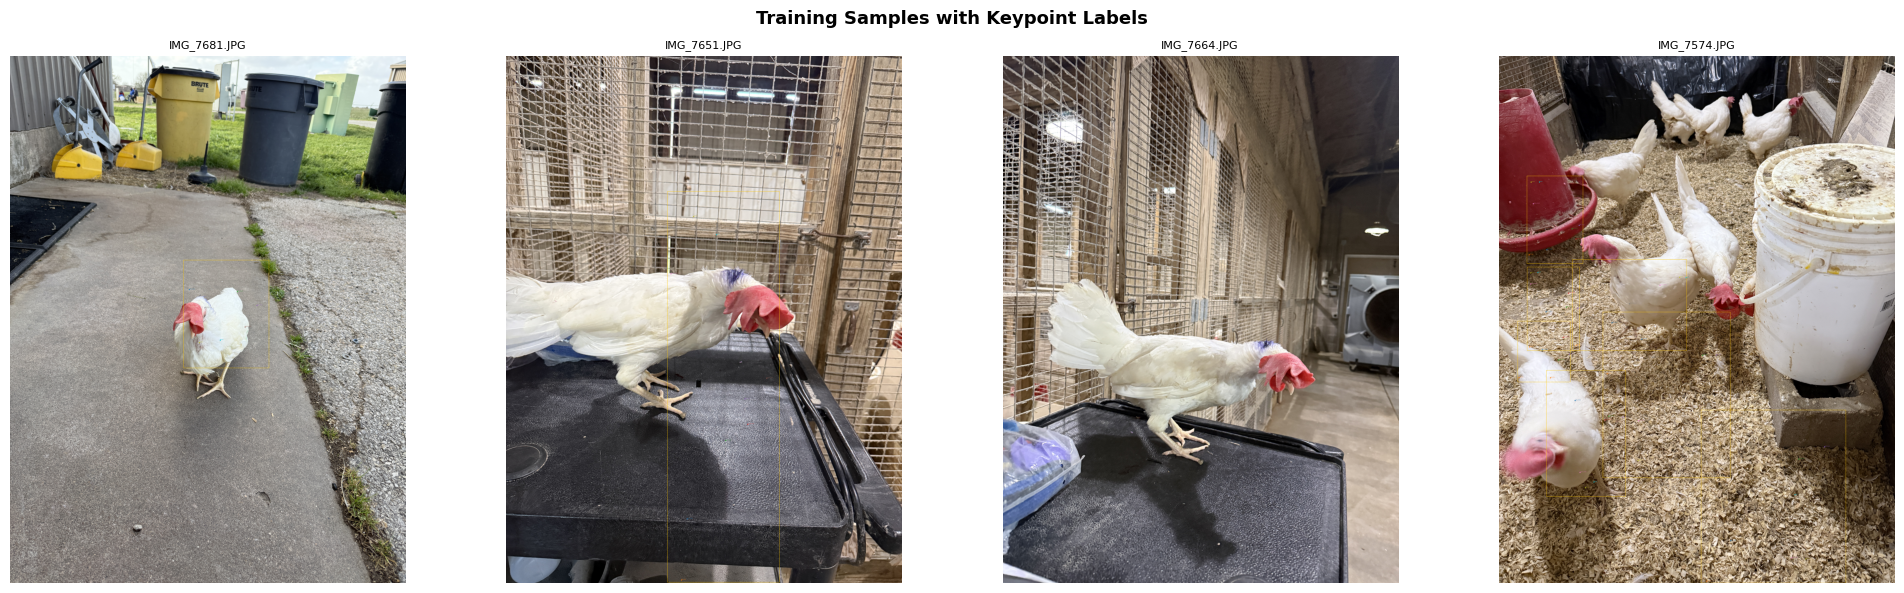

In [5]:
# Visualise a few training samples with their keypoint labels
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

KEYPOINT_NAMES = cfg["kpt_names"][0]
COLORS = plt.cm.tab10(np.linspace(0, 1, len(KEYPOINT_NAMES)))

def draw_pose(img_path, lbl_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    with open(lbl_path) as f:
        for line in f:
            vals = list(map(float, line.split()))
            # bbox
            cx, cy, bw, bh = vals[1]*w, vals[2]*h, vals[3]*w, vals[4]*h
            x1,y1 = int(cx-bw/2), int(cy-bh/2)
            x2,y2 = int(cx+bw/2), int(cy+bh/2)
            cv2.rectangle(img, (x1,y1),(x2,y2),(255,200,0),2)
            # keypoints
            kps = vals[5:]
            for i in range(0, len(kps), 3):
                kx, ky, vis = kps[i]*w, kps[i+1]*h, kps[i+2]
                if vis > 0:
                    c = tuple((np.array(COLORS[i//3][:3])*255).astype(int).tolist())
                    cv2.circle(img,(int(kx),int(ky)),6,c,-1)
                    cv2.putText(img, KEYPOINT_NAMES[i//3],(int(kx)+4,int(ky)-4),
                                cv2.FONT_HERSHEY_SIMPLEX,0.4,c,1)
    return img

samples = random.sample(train_imgs, min(4, len(train_imgs)))
fig, axes = plt.subplots(1, len(samples), figsize=(20, 6))
for ax, img_path in zip(axes, samples):
    lbl_path = DATASET_ROOT / "labels" / "train" / (img_path.stem + ".txt")
    ax.imshow(draw_pose(img_path, lbl_path))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
plt.suptitle("Training Samples with Keypoint Labels", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Training Configuration

In [6]:
# ── Tune these based on your GPU VRAM ────────────────────────────────────────
# VRAM  4 GB  →  batch=4,  imgsz=640
# VRAM  8 GB  →  batch=8,  imgsz=640
# VRAM 16 GB  →  batch=16, imgsz=800
# VRAM 24 GB+ →  batch=32, imgsz=1024

TRAIN_CFG = dict(
    data      = str(data_yaml.resolve()),
    model     = "yolo12n-pose.pt",   # nano — good start for small dataset
    epochs    = 50,
    imgsz     = 640,
    batch     = 8,                   # adjust to your VRAM
    patience  = 30,                  # early stop
    optimizer = "AdamW",
    lr0       = 0.001,
    lrf       = 0.01,
    warmup_epochs = 5,
    # Augmentation — important for small datasets
    hsv_h     = 0.015,
    hsv_s     = 0.5,
    hsv_v     = 0.3,
    flipud    = 0.0,               # hens are always upright
    fliplr    = 0.5,
    mosaic    = 0.5,
    mixup     = 0.1,
    degrees   = 10.0,
    translate = 0.1,
    scale     = 0.5,
    # Output
    project   = "runs/pose",
    name      = "hen_pose_v1",
    exist_ok  = True,
    verbose   = True,
    plots     = True,
)

print("Training config:")
for k, v in TRAIN_CFG.items():
    print(f"  {k:<20} {v}")

Training config:
  data                 /home/ogbi/Development/poultry-vision/pose-v1/data.yaml
  model                yolo12n-pose.pt
  epochs               50
  imgsz                640
  batch                8
  patience             30
  optimizer            AdamW
  lr0                  0.001
  lrf                  0.01
  warmup_epochs        5
  hsv_h                0.015
  hsv_s                0.5
  hsv_v                0.3
  flipud               0.0
  fliplr               0.5
  mosaic               0.5
  mixup                0.1
  degrees              10.0
  translate            0.1
  scale                0.5
  project              runs/pose
  name                 hen_pose_v1
  exist_ok             True
  verbose              True
  plots                True


## 4. Train

In [7]:
model = YOLO(TRAIN_CFG["model"])
results = model.train(**TRAIN_CFG)

print("\n✅ Training complete")
print(f"Best weights : {results.save_dir}/weights/best.pt")

FileNotFoundError: [Errno 2] No such file or directory: 'yolo12n-pose.pt'

## 5. Evaluate on Validation Set

In [ ]:
best_weights = Path(results.save_dir) / "weights" / "best.pt"
model_best = YOLO(str(best_weights))

metrics = model_best.val(data=str(data_yaml.resolve()), plots=True)

print(f"\nBox mAP50       : {metrics.box.map50:.4f}")
print(f"Box mAP50-95    : {metrics.box.map:.4f}")
print(f"Pose mAP50      : {metrics.pose.map50:.4f}")
print(f"Pose mAP50-95   : {metrics.pose.map:.4f}")

## 6. Training Curves

In [ ]:
import pandas as pd

results_csv = Path(results.save_dir) / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("YOLOv12 Hen Pose Training Curves", fontsize=15, fontweight="bold")

plots = [
    ("train/box_loss",  "val/box_loss",  "Box Loss"),
    ("train/pose_loss", "val/pose_loss", "Pose Loss"),
    ("train/kobj_loss", "val/kobj_loss", "Keypoint Obj Loss"),
    ("metrics/mAP50(B)",    None, "Box mAP@50"),
    ("metrics/mAP50(P)",    None, "Pose mAP@50"),
    ("metrics/mAP50-95(P)", None, "Pose mAP@50-95"),
]

for ax, (train_col, val_col, title) in zip(axes.flat, plots):
    if train_col in df.columns:
        ax.plot(df["epoch"], df[train_col], label="train", linewidth=2)
    if val_col and val_col in df.columns:
        ax.plot(df["epoch"], df[val_col], label="val", linewidth=2, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 7. Inference on Validation Images

In [ ]:
val_sample = random.sample(val_imgs, min(6, len(val_imgs)))

preds = model_best.predict(
    source=val_sample,
    conf=0.25,
    imgsz=640,
    save=False,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Validation Predictions", fontsize=14, fontweight="bold")

for ax, r in zip(axes.flat, preds):
    annotated = r.plot()
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    n_hens = len(r.boxes)
    ax.set_title(f"{Path(r.path).name} | {n_hens} hen(s)")
    ax.axis("off")

plt.tight_layout()
plt.savefig("val_predictions.png", dpi=150)
plt.show()

## 8. Export Best Model

In [ ]:
# Export to ONNX for deployment (e.g. on Raspberry Pi or inference server)
model_best.export(format="onnx", imgsz=640, simplify=True)

print(f"\nBest PT weights : {best_weights}")
print(f"ONNX model      : {str(best_weights).replace('.pt', '.onnx')}")

## 9. Next Steps

| Step | Description |
|------|-------------|
| **More data** | Label more frames from your RTSP recordings to improve generalisation |
| **SAM 2 pseudo-labels** | Use SAM 2 video propagation to generate labels from unlabelled clips (Experiment 2) |
| **Larger model** | Swap `yolo12n-pose.pt` → `yolo12s-pose.pt` once dataset grows |
| **Pi deployment** | Use the exported ONNX model with `model.predict()` on the Pi's live RTSP feed |
| **Welfare metrics** | Feed pose outputs into activity index / gait scoring pipeline |